<a href="https://colab.research.google.com/github/Fathima-Rinsha-k/Fathima-Rinsha-k/blob/main/Rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

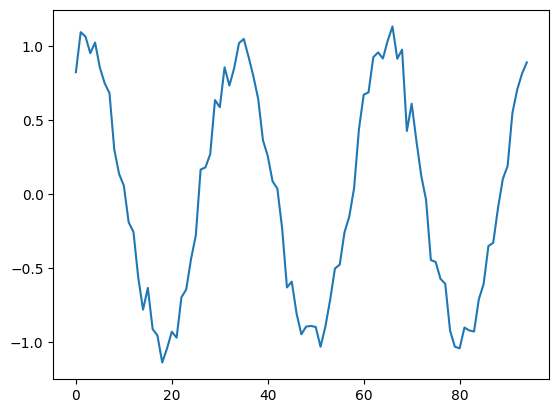

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Simulated GDP growth rate in %
np.random.seed(42)
time_steps = 100
gdp_growth = np.sin(np.linspace(0, 20, time_steps)) + np.random.normal(0, 0.1, time_steps)

sequence_length = 5
plt.plot(gdp_growth[sequence_length:], label="Actual GDP Growth")

plt.show()

In [ ]:
# dataset for RNN
sequence_length = 5
X, y = [], []
for i in range(len(gdp_growth) - sequence_length):
    X.append(gdp_growth[i:i + sequence_length])
    y.append(gdp_growth[i + sequence_length])
X = np.array(X)
y = np.array(y)

# Convert data to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

In [ ]:
# simple RNN model
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), self.hidden_size)  # Initial hidden state
        out, _ = self.rnn(x, h0)  # RNN forward pass
        out = self.fc(out[:, -1, :])  # Fully connected layer on last time step
        return out

In [ ]:
# Model hyperparameters
input_size = 1  # Single feature (GDP growth)
hidden_size = 16
output_size = 1
learning_rate = 0.01
epochs = 100
